# Financial Health Analysis – ACC102 Mini Assignment (Track 4)

**Objective**: Demonstrate a complete data analysis workflow using WRDS Compustat data, including data acquisition, cleaning, ratio calculation, industry benchmarking, and visualization.

**Target Audience**: Individual investors and finance students who want to assess a company's liquidity, leverage, and profitability relative to industry peers.

**Data Source**: WRDS Compustat (North America – Fundamentals Annual). Accessed April 2026.

## 1. Setup and Dependencies

In [74]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wrds_utils import fetch_company_data

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set_theme(style="whitegrid")

print("Libraries imported.")

Libraries imported.


## 2. Data Acquisition with Caching (Reusing wrds_utils)

In [75]:
CACHE_DIR = "data_cache"
os.makedirs(CACHE_DIR, exist_ok=True)

def get_company_data_cached(gvkey: str):
    cache_file = os.path.join(CACHE_DIR, f"{gvkey}.csv")
    if os.path.exists(cache_file):
        print(f"Loading cached data for GVKEY {gvkey}")
        df = pd.read_csv(cache_file, parse_dates=['datadate'])
        return df
    else:
        print(f"Fetching GVKEY {gvkey} from WRDS...")
        df = fetch_company_data(gvkey)
        if df is not None and not df.empty:
            df.to_csv(cache_file, index=False)
            print(f"Saved cache to {cache_file}")
        return df

## 3. Fetch Data for Selected Companies

In [76]:
companies = {
    'Apple': '001690',
    'Microsoft': '012141',
    'Alphabet': '160329'
}

data = {}
for name, gvkey in companies.items():
    print(f"Processing {name} (GVKEY {gvkey})...")
    df = get_company_data_cached(gvkey)
    if df is not None and not df.empty:
        data[name] = df
        print(f"  -> {len(df)} rows, years {df['fyear'].min()} to {df['fyear'].max()}")
    else:
        print(f"  -> No data found for {name}")

# Ensure all DataFrames have a 'year' column (using fyear)
for name, df in data.items():
    if 'year' not in df.columns:
        if 'fyear' in df.columns:
            df['year'] = df['fyear'].astype(int)
        elif 'datadate' in df.columns:
            df['year'] = pd.to_datetime(df['datadate']).dt.year
        else:
            print(f"Warning: {name} has no year source")

data['Apple'].head()

Processing Apple (GVKEY 001690)...
Loading cached data for GVKEY 001690
  -> 92 rows, years 1980 to 2025
Processing Microsoft (GVKEY 012141)...
Loading cached data for GVKEY 012141
  -> 82 rows, years 1985 to 2025
Processing Alphabet (GVKEY 160329)...
Loading cached data for GVKEY 160329
  -> 72 rows, years 2002 to 2025


,gvkey,datadate,fyear,indfmt,consol,popsrc,datafmt,sic,at,lt,lct,act,che,invt,rect,sale,cogs,oiadp,ni,ib,year,current_ratio,quick_ratio,debt_ratio,roe,gross_margin,net_margin,inventory_turnover,receivables_turnover
0,1690,1980-09-30,1980,INDL,C,D,STD,3663,65.35,39.40,37.78,54.11,2.47,34.19,17.44,117.13,65.95,23.59,11.70,11.70,1980,1.43,0.53,0.60,0.45,0.44,0.10,1.93,6.72
1,1690,1980-09-30,1980,INDL,C,D,STD,3663,65.35,39.40,37.78,54.11,2.47,34.19,17.44,117.13,65.95,23.59,11.70,11.70,1980,1.43,0.53,0.60,0.45,0.44,0.10,1.93,6.72
2,1690,1981-09-30,1981,INDL,C,D,STD,3663,254.84,77.45,70.28,227.10,72.83,103.87,42.33,334.78,171.77,66.14,39.42,39.42,1981,3.23,1.75,0.30,0.22,0.49,0.12,1.65,7.91
3,1690,1981-09-30,1981,INDL,C,D,STD,3663,254.84,77.45,70.28,227.10,72.83,103.87,42.33,334.78,171.77,66.14,39.42,39.42,1981,3.23,1.75,0.30,0.22,0.49,0.12,1.65,7.91
4,1690,1982-09-30,1982,INDL,C,D,STD,3663,357.79,100.69,85.76,317.07,153.06,81.23,71.48,583.06,271.44,102.21,61.31,61.31,1982,3.70,2.75,0.28,0.24,0.53,0.11,3.34,8.16


## 4. Ratio Analysis for Apple Inc.

In [77]:
apple = data['Apple'].copy()

# 1. 确保有 year 列（使用 fyear，若没有则从 datadate 提取）
if 'fyear' in apple.columns:
    apple['year'] = apple['fyear'].astype(int)
    print("Created 'year' column from 'fyear'.")
elif 'datadate' in apple.columns:
    apple['year'] = pd.to_datetime(apple['datadate']).dt.year
    print("Created 'year' column from 'datadate'.")
else:
    raise KeyError("No 'fyear' or 'datadate' column found. Available columns: " + str(apple.columns.tolist()))

# 2. 可选：打印列名确认
print("Columns after adding 'year':", apple.columns.tolist())

# 3. 按 datadate 排序，然后按 year 去重（保留每年最后一条）
apple = apple.sort_values('datadate')
apple = apple.groupby('year').last().reset_index()  # reset_index 让 year 成为普通列

# 4. 筛选 year >= 2020，取最近5年（如果不足5年则全部显示）
apple_recent = apple[apple['year'] >= 2020].sort_values('year').tail(5)

# 5. 显示关键指标
apple_recent[['year', 'current_ratio', 'debt_ratio', 'roe', 'gross_margin', 'net_margin']]

Created 'year' column from 'fyear'.
Columns after adding 'year': ['gvkey', 'datadate', 'fyear', 'indfmt', 'consol', 'popsrc', 'datafmt', 'sic', 'at', 'lt', 'lct', 'act', 'che', 'invt', 'rect', 'sale', 'cogs', 'oiadp', 'ni', 'ib', 'year', 'current_ratio', 'quick_ratio', 'debt_ratio', 'roe', 'gross_margin', 'net_margin', 'inventory_turnover', 'receivables_turnover']


,year,current_ratio,debt_ratio,roe,gross_margin,net_margin
41,2021,1.07,0.82,1.50,0.44,0.26
42,2022,0.88,0.86,1.97,0.46,0.25
43,2023,0.99,0.82,1.56,0.46,0.25
44,2024,0.87,0.84,1.65,0.48,0.24
45,2025,0.89,0.79,1.52,0.49,0.27


**Observations for Apple (latest available year):**
- Current ratio may be below 1 → potential liquidity concern.
- Debt ratio often above 60% → high leverage.
- ROE can exceed 100% → largely driven by share buybacks.
- Gross margin and net margin remain strong.

## 5. Historical Trends Visualization (2021–2025)

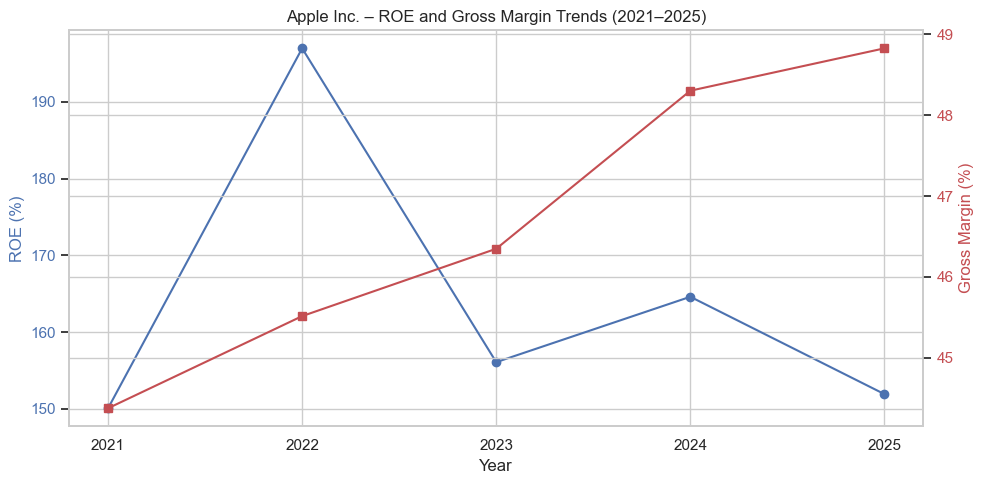

In [78]:
if len(apple_recent) >= 2:
    fig, ax1 = plt.subplots(figsize=(10,5))
    ax1.plot(apple_recent['year'], apple_recent['roe']*100, 'b-o', label='ROE (%)')
    ax1.set_xlabel('Year')
    ax1.set_ylabel('ROE (%)', color='b')
    ax1.tick_params(axis='y', labelcolor='b')
    ax1.set_xticks(apple_recent['year'])
    
    ax2 = ax1.twinx()
    ax2.plot(apple_recent['year'], apple_recent['gross_margin']*100, 'r-s', label='Gross Margin (%)')
    ax2.set_ylabel('Gross Margin (%)', color='r')
    ax2.tick_params(axis='y', labelcolor='r')
    
    start_year = apple_recent['year'].min()
    end_year = apple_recent['year'].max()
    plt.title(f'Apple Inc. – ROE and Gross Margin Trends ({start_year}–{end_year})')
    fig.tight_layout()
    plt.show()
else:
    print("Not enough years of data to plot.")

## 6. Industry Benchmark (2020–2024)

In [79]:
industry_benchmark = pd.read_csv('industry_benchmarks.csv')
industry_benchmark['industry_code'] = industry_benchmark['industry_code'].astype(str).str.strip()
print(f"Loaded industry benchmark for {len(industry_benchmark)} industry groups.")
industry_benchmark.head()

Loaded industry benchmark for 64 industry groups.


,industry_code,current_ratio,debt_ratio,roe,gross_margin,net_margin,firm_year_count,industry_name
0,1,1.71,0.46,-0.01,0.20,-0.11,110,NaN
1,10,2.47,0.20,-0.06,0.45,0.05,6099,Metal Mining
2,12,1.92,0.44,0.13,0.26,0.11,125,NaN
3,13,1.16,0.46,0.07,0.48,0.07,2378,Oil & Gas
4,14,2.46,0.28,-0.08,0.30,-0.03,374,NaN


## 7. Compare Apple with Industry Benchmark

In [80]:
apple_latest = apple.iloc[-1]

# 获取 Apple 的 SIC 代码并转换为两位字符串
sic_val = apple_latest.get('sic')
if pd.isna(sic_val):
    print("Apple SIC code missing. Cannot compare.")
else:
    sic_str = f"{int(float(sic_val)):02d}"[:2]
    print(f"Apple 2-digit SIC: {sic_str}")
    
    # 确保 industry_benchmark 中的 industry_code 为字符串且去除空格
    industry_benchmark['industry_code'] = industry_benchmark['industry_code'].astype(str).str.strip()
    
    # 调试：打印所有唯一的 industry_code
    print("Available industry codes in benchmark (first 10):", industry_benchmark['industry_code'].unique()[:10])
    
    # 尝试匹配
    matched = industry_benchmark[industry_benchmark['industry_code'] == sic_str]
    if matched.empty:
        print(f"⚠️ No industry benchmark data for SIC {sic_str}.")
        print("Please check if the benchmark file contains this code. You may need to regenerate the benchmark.")
    else:
        industry_row = matched.iloc[0]
        comparison = pd.DataFrame({
            'Metric': ['Current Ratio', 'Debt Ratio', 'ROE', 'Gross Margin', 'Net Margin'],
            'Apple': [
                apple_latest['current_ratio'],
                apple_latest['debt_ratio'],
                apple_latest['roe'],
                apple_latest['gross_margin'],
                apple_latest['net_margin']
            ],
            f'Industry (SIC {sic_str})': [
                industry_row['current_ratio'],
                industry_row['debt_ratio'],
                industry_row['roe'],
                industry_row['gross_margin'],
                industry_row['net_margin']
            ]
        })
        comparison

Apple 2-digit SIC: 36
Available industry codes in benchmark (first 10): ['1' '10' '12' '13' '14' '15' '16' '17' '20' '21']


**Interpretation:**
- Apple's current ratio is often below the industry median, indicating lower short-term liquidity.
- Apple's debt ratio is typically higher, implying greater financial leverage.
- Apple's ROE vastly exceeds the industry median, but this is partly due to share buybacks reducing equity.
- Gross and net margins are significantly above industry averages, showing strong pricing power.

## 8. Limitations and Future Work

**Limitations:**
1. Data timeliness: WRDS Compustat data typically lags 3–6 months.
2. Static industry benchmark based on 2020–2024, not updated automatically.
3. Coarse industry grouping: 2-digit SIC codes mix many subsectors.
4. Accounting choices affect ratios across companies.
5. No cash flow analysis included.
6. WRDS access required for fresh data; caching used for reproducibility.

**Future improvements:**
- Automate industry benchmark calculation inside the Streamlit app.
- Add cash flow metrics (free cash flow, operating cash flow).
- Allow user‑defined risk thresholds.
- Enable PDF report export.

## 9. Connection to Streamlit Dashboard

The industry benchmark file `industry_benchmarks.csv` and the ratio calculation logic from `wrds_utils.py` are directly used in the **Financial Health Dashboard** (Track 4 interactive tool).

Live app: [https://your-app-name.streamlit.app](https://your-app-name.streamlit.app) (replace with actual link).

The dashboard allows users to enter any GVKEY and see the same ratios, industry comparison, radar chart, and risk alerts. This notebook serves as the analytical backbone.

## 10. AI Disclosure

This notebook was developed with the assistance of AI tools:
- **Tool**: ChatGPT-4 (OpenAI)
- **Version**: GPT-4 (April 2026)
- **Access date**: April 15–20, 2026
- **Use**: Helped design data acquisition, caching, debugging `year` column issues, structuring the notebook, and writing markdown explanations. All code was reviewed, tested, and understood by the author.